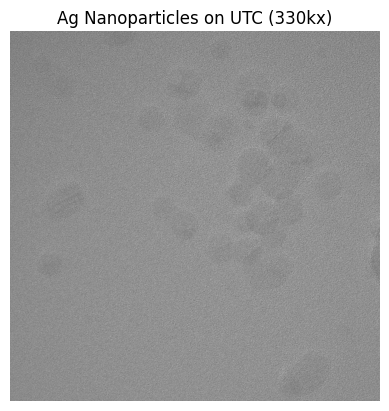

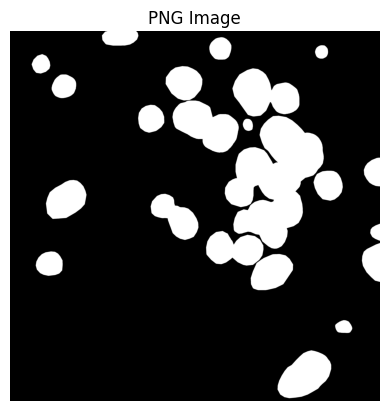

In [1]:
from ncempy.io import dm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

file = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_02.dm3")
label_file = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/Labels/20220202_Ag_UTC_330kx_2650e_0p1596s_02_label.png")

# Load the DM3 file
data_dict = dm.dmReader(str(file.resolve()))

image_data = data_dict['data']
plt.imshow(image_data, cmap='gray')
plt.title("Ag Nanoparticles on UTC (330kx)")
plt.axis('off') 
plt.show()


img = mpimg.imread(label_file)

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title("PNG Image")
plt.show()

In [2]:
from skimage.util import view_as_windows

def split_patches(patch_size, image, stride):
    blocks = view_as_windows(image, window_shape=(patch_size, patch_size), step=stride)
    patches = blocks.reshape(-1, patch_size, patch_size)

    return patches

In [3]:
patched_image = split_patches(64, image_data, 16)

In [4]:
from scipy import ndimage
from persim import plot_diagrams
from ripser import lower_star_img
from persim import PersistenceImager
import numpy as np

pimgr = PersistenceImager(
    pixel_size=0.02,
    birth_range=(0, 2),
)

def PH_patch(patched_image, scale_percentile=95):
    dgms = []
    for p in patched_image:
        dgm = lower_star_img(p)
        dgm = dgm[np.isfinite(dgm[:, 1])]

        if len(dgm) == 0:
            dgms.append(dgm)
            continue

        births = dgm[:, 0]
        deaths = dgm[:, 1]

        # 1. birth offset normalisation — removes illumination offset
        min_birth = births.min()
        births = births - min_birth
        deaths = deaths - min_birth

        # 2. robust scale normalisation — removes contrast/dynamic-range
        # differences without letting a single outlier dominate
        scale = np.percentile(deaths, scale_percentile)
        if scale <= 0:
            scale = 1.0  # guard against degenerate all-zero diagrams

        births = births / scale
        deaths = deaths / scale

        dgm_norm = np.column_stack([births, deaths])
        dgms.append(dgm_norm)


    vectors = []
    for dgm in dgms:
        pimg = pimgr.transform(dgm)
        vec = pimg.ravel()
        vectors.append(vec)
    vectors = np.vstack(vectors)

    return dgms, vectors

dgms, vectorised_patches = PH_patch(patched_image)


In [72]:
lengths = [len(d) for d in dgms]
print("empty diagrams:", sum(1 for l in lengths if l == 0), "/", len(lengths))
print("vector shapes:", set(v.shape for v in vectorised_patches))

empty diagrams: 0 / 64009
vector shapes: {(5000,)}


/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_121101/3331302418.py:17: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


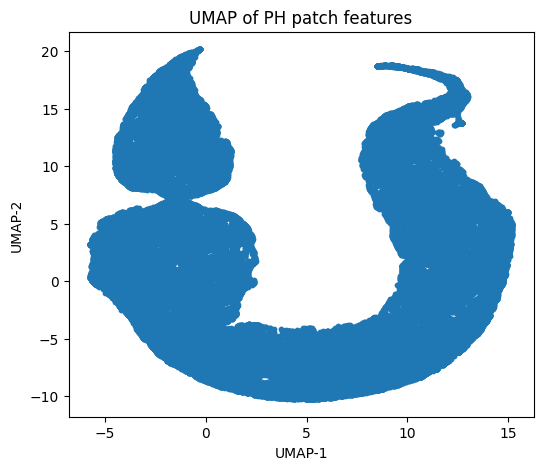

In [5]:
from sklearn.preprocessing import StandardScaler
import umap

X = StandardScaler().fit_transform(vectorised_patches)

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

embedding = reducer.fit_transform(X)

plt.figure(figsize=(6,5))
plt.scatter(
    embedding[:,0],
    embedding[:,1],
    s=10,
    cmap="Spectral"
)
plt.title("UMAP of PH patch features")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

In [6]:
def get_positions(image_data):

    blocks = view_as_windows(image_data, window_shape=(64, 64), step=16)
    n_rows, n_cols = blocks.shape[:2]

    positions = [
        (i * 16, j * 16)
        for i in range(n_rows)
        for j in range(n_cols)
    ]

    return positions

In [7]:
import numpy as np

def label_to_image(original_image, labels, positions):

    H, W = original_image.shape[:2]
    label_img = np.zeros((H, W), dtype=int)

    for (r, c), lab in zip(positions, labels):
        label_img[r:r+16, c:c+16] = lab

    return label_img

UMAP + GMM

In [10]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=8, covariance_type="full")
labels = gmm.fit_predict(embedding)
positions = get_positions(image_data)
probs = gmm.predict_proba(embedding)

label_img = label_to_image(image_data, labels, positions)

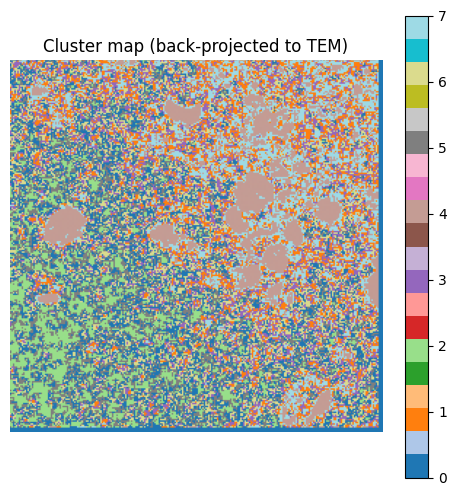

In [11]:
plt.figure(figsize=(6,6))
plt.imshow(label_img, cmap="tab20")
plt.title("Cluster map (back-projected to TEM)")
plt.colorbar()
plt.axis("off")
plt.show()

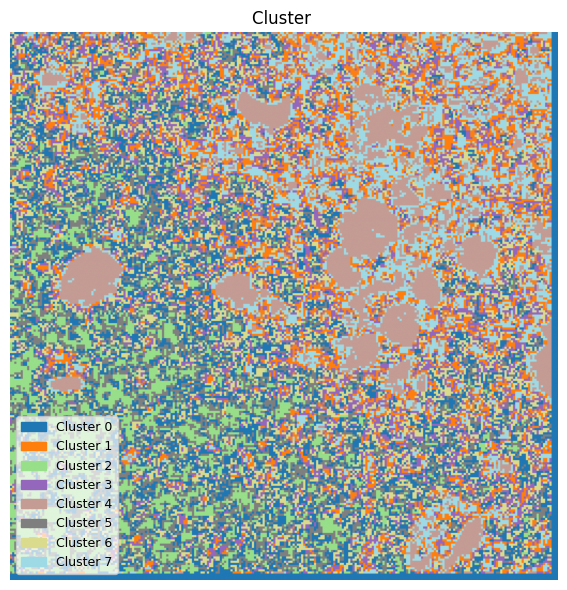

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

plt.figure(figsize=(6,6))

clusters = np.unique(label_img)
cmap = plt.get_cmap("tab20", len(clusters))

plt.imshow(label_img, cmap=cmap)

plt.title("Cluster ")
plt.axis("off")

legend_patches = [
    mpatches.Patch(color=cmap(i), label=f"Cluster {c}")
    for i, c in enumerate(clusters)
]

plt.legend(
    handles=legend_patches,
    loc="lower left",          # inside plot
    frameon=True,             # box around legend
    framealpha=0.7,           # semi-transparent
    fontsize=9
)

plt.tight_layout()
plt.show()

/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/skimage/_shared/utils.py:386: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  return func(*args, **kwargs)
/tmp/ipykernel_121101/833023456.py:11: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean_mask = binary_closing(clean_mask, footprint=disk(2))


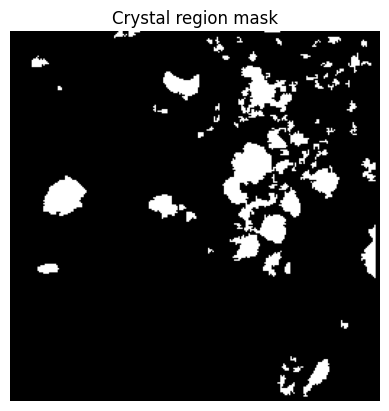

In [13]:
from skimage.morphology import remove_small_objects
from scipy.ndimage import binary_fill_holes
from skimage.morphology import binary_closing, disk

target_cluster = 4

mask = (label_img == target_cluster).astype(np.uint8)

clean_mask = remove_small_objects(mask, max_size=100)
clean_mask = binary_fill_holes(clean_mask)
clean_mask = binary_closing(clean_mask, footprint=disk(2))
clean_mask = remove_small_objects(clean_mask, max_size=1600)
plt.imshow(clean_mask, cmap="gray")
plt.title("Crystal region mask")
plt.axis("off")
plt.show()

In [14]:
accuracy = np.mean(clean_mask == img) * 100
print(f"Accuracy: {accuracy:.2f}%")       
truth_mask = (img > 0)             

intersection = (clean_mask & truth_mask).sum()
union        = (clean_mask | truth_mask).sum()

iou  = intersection / union                              
dice = 2 * intersection / (clean_mask.sum() + truth_mask.sum()) if (clean_mask.sum() + truth_mask.sum()) > 0 else 0.0

intersection = (clean_mask & truth_mask).sum()
    
precision = intersection / clean_mask.sum()                    
recall    = intersection / truth_mask.sum()                         
f1        = 2 * precision * recall / (precision + recall)          

print(f"Precision: {precision:.3f}  Recall: {recall:.3f}  F1: {f1:.3f}")

print(f"IoU: {iou:.3f}  Dice: {dice:.3f}")


Accuracy: 88.08%
Precision: 0.840  Recall: 0.406  F1: 0.548
IoU: 0.377  Dice: 0.548


Density Analysis

In [ ]:
from scipy.stats import gaussian_kde

def cluster_persistence_density(dgms_in_cluster, grid_size=100, bw_method=None):
    all_points = np.vstack([d for d in dgms_in_cluster if len(d) > 0])
    births = all_points[:, 0]
    lifetimes = all_points[:, 1] - all_points[:, 0]

    coords = np.vstack([births, lifetimes])
    kde = gaussian_kde(coords, bw_method=bw_method)

    # evaluate on a grid for visualisation
    b_min, b_max = births.min(), births.max()
    l_min, l_max = lifetimes.min(), lifetimes.max()

    bb, ll = np.meshgrid(
        np.linspace(b_min, b_max, grid_size),
        np.linspace(l_min, l_max, grid_size)
    )
    grid_coords = np.vstack([bb.ravel(), ll.ravel()])
    density_grid = kde(grid_coords).reshape(grid_size, grid_size)

    return kde, density_grid, (b_min, b_max, l_min, l_max)

In [16]:
cluster_densities = {}
for label in np.unique(labels):
    indices = np.where(labels == label)[0]
    cluster_dgms = [dgms[i] for i in indices]
    kde, density_grid, extent = cluster_persistence_density(cluster_dgms)
    cluster_densities[label] = (density_grid, extent)

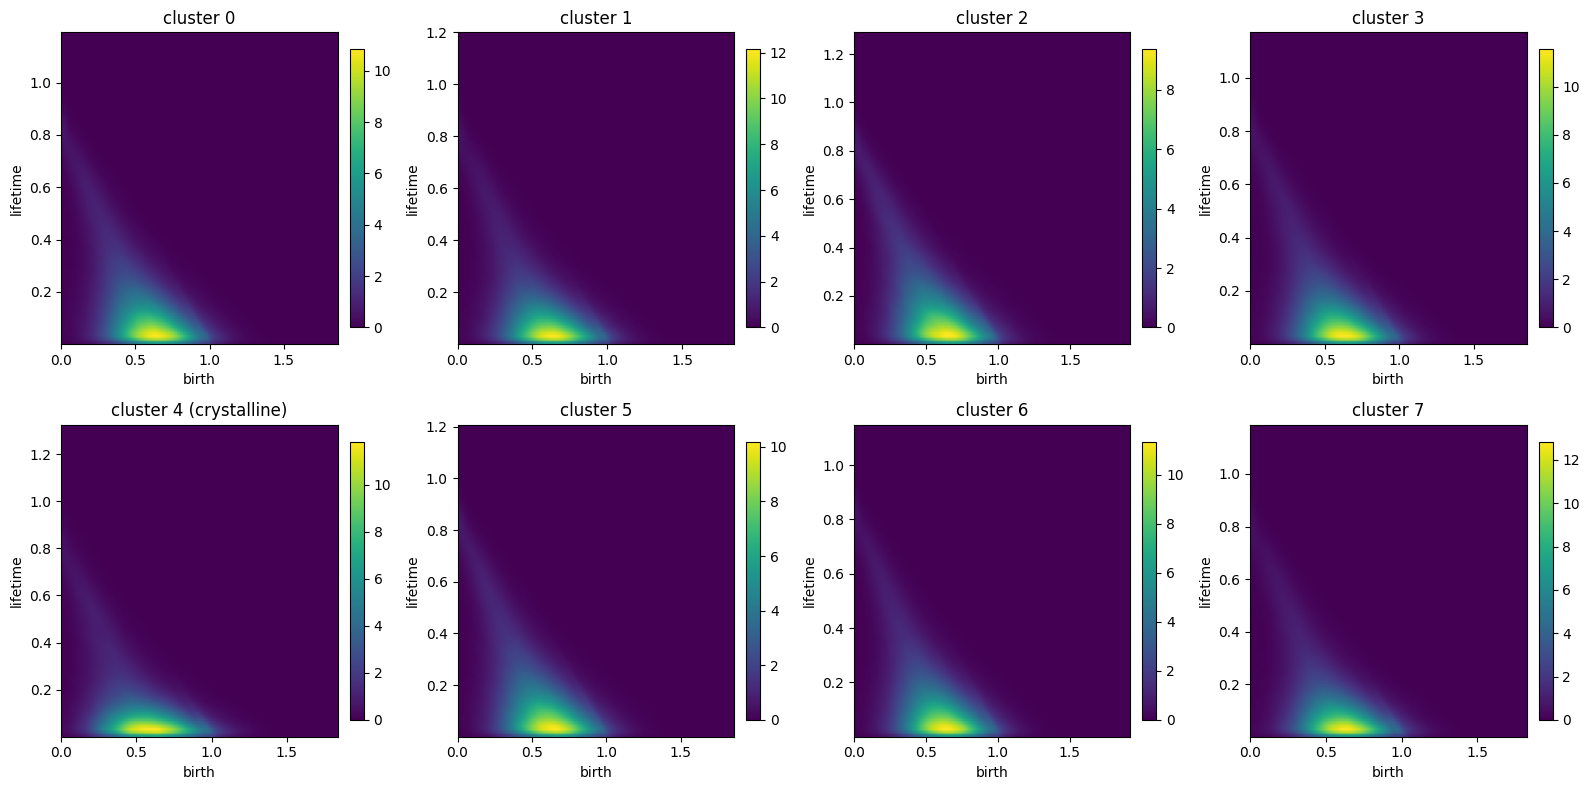

In [ ]:
n_clusters = len(cluster_densities)
n_cols = 4
n_rows = int(np.ceil(n_clusters / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, (label, (density_grid, extent)) in zip(axes, cluster_densities.items()):
    im = ax.imshow(density_grid, origin='lower', extent=extent, aspect='auto', cmap='viridis')
    ax.set_title(f"cluster {label}" + (" (crystalline)" if label == 4 else ""))
    ax.set_xlabel("birth")
    ax.set_ylabel("lifetime")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# hide any unused subplot axes
for ax in axes[len(cluster_densities):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

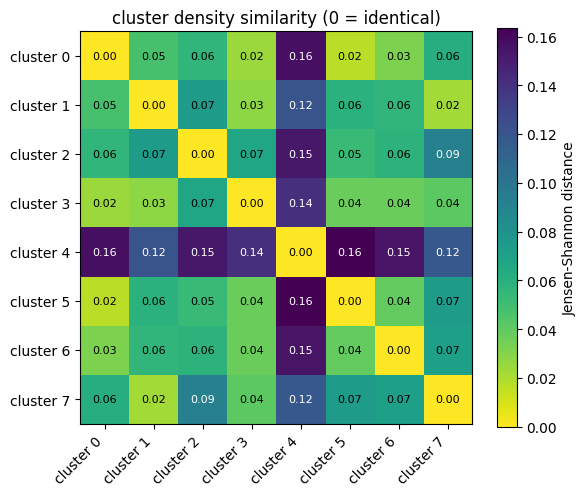

In [18]:
from scipy.spatial.distance import jensenshannon

def normalise_density(density_grid, eps=1e-10):
    flat = density_grid.ravel()
    flat = np.clip(flat, 0, None)
    flat = flat + eps
    return flat / flat.sum()

labels_sorted = sorted(cluster_densities.keys())
n = len(labels_sorted)

similarity_matrix = np.zeros((n, n))

for i, li in enumerate(labels_sorted):
    for j, lj in enumerate(labels_sorted):
        di = normalise_density(cluster_densities[li][0])
        dj = normalise_density(cluster_densities[lj][0])
        similarity_matrix[i, j] = jensenshannon(di, dj)  # 0 = identical, 1 = maximally different

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(similarity_matrix, cmap='viridis_r', vmin=0, vmax=similarity_matrix.max())

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels([f"cluster {l}" for l in labels_sorted], rotation=45, ha='right')
ax.set_yticklabels([f"cluster {l}" for l in labels_sorted])

for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{similarity_matrix[i,j]:.2f}", ha='center', va='center',
                 color='white' if similarity_matrix[i,j] > similarity_matrix.max()/2 else 'black',
                 fontsize=8)

fig.colorbar(im, label="Jensen-Shannon distance")
plt.title("cluster density similarity (0 = identical)")
plt.tight_layout()
plt.show()

Density Application

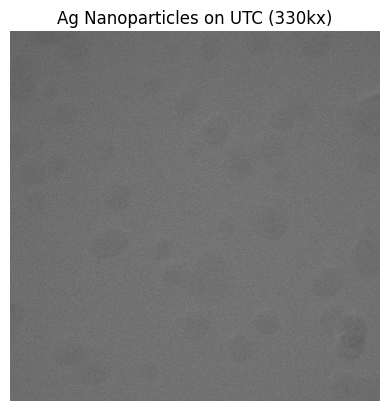

In [22]:
test_file = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_03.dm3")
test_data_dict = dm.dmReader(str(test_file.resolve()))

test_image_data = test_data_dict['data']

plt.imshow(test_image_data, cmap='gray')
plt.title("Ag Nanoparticles on UTC (330kx)")
plt.axis('off') 
plt.show()

In [23]:
import glob
import os
from ncempy.io import dm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.preprocessing import StandardScaler
import umap
from sklearn.cluster import KMeans
from skimage.util import view_as_windows             
from skimage.transform import resize
from scipy.ndimage import gaussian_filter
import numpy as np
from persim import PersistenceImager
from ripser import lower_star_img
import pandas as pd
from itertools import islice
import tifffile
from skimage.restoration import denoise_nl_means
from scipy.stats import gaussian_kde
import json
from persim import plot_diagrams

test_patched_image = split_patches(64, test_image_data, 16)
test_dgms, test_vectorised_patches = PH_patch(test_patched_image)

test_positions = get_positions(test_image_data)

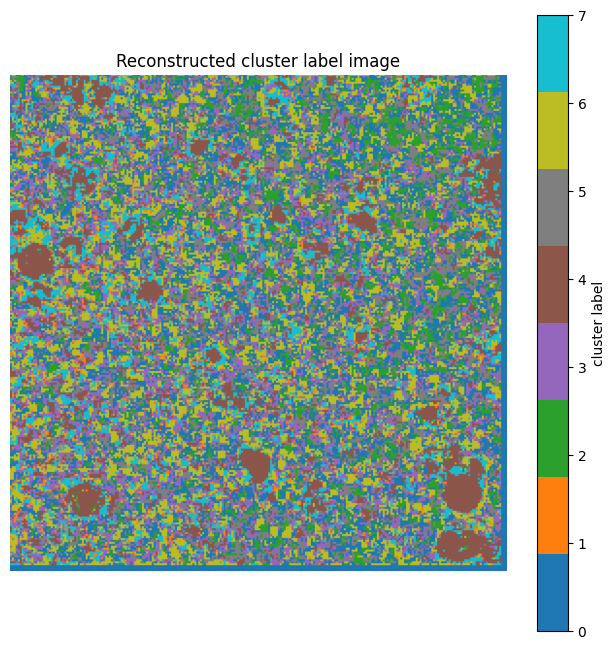

In [45]:
import numpy as np
from scipy.interpolate import RegularGridInterpolator

def score_dgm_against_clusters(dgm, cluster_densities):
    if len(dgm) == 0:
        return None, {}

    births = dgm[:, 0]
    lifetimes = dgm[:, 1] - dgm[:, 0]

    scores = {}
    for label, (density_grid, extent) in cluster_densities.items():
        b_min, b_max, l_min, l_max = extent
        grid_size = density_grid.shape[0]

        interpolator = RegularGridInterpolator(
            (np.linspace(l_min, l_max, grid_size), np.linspace(b_min, b_max, grid_size)),
            density_grid,
            bounds_error=False,
            fill_value=1e-12,
        )

        query_points = np.column_stack([lifetimes, births])
        densities = np.clip(interpolator(query_points), 1e-12, None)
        scores[label] = np.mean(np.log(densities))

    best_label = max(scores, key=scores.get)
    return best_label, scores

best_labels = []
for dgm in test_dgms:                      # your existing diagrams for the new image
    best_label, scores = score_dgm_against_clusters(dgm, cluster_densities)
    best_labels.append(best_label)


test_label_image = label_to_image(image_data, best_labels,  test_positions )

n_clusters = len(cluster_densities)
cmap = plt.get_cmap("tab10", n_clusters)
cmap.set_under("black")  # colour for uncovered (-1) pixels

plt.figure(figsize=(8, 8))
plt.imshow(test_label_image, cmap=cmap, vmin=0, vmax=n_clusters - 1)
plt.colorbar(ticks=range(n_clusters), label="cluster label")
plt.title("Reconstructed cluster label image")
plt.axis("off")
plt.show()

/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/skimage/_shared/utils.py:386: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  return func(*args, **kwargs)
/tmp/ipykernel_121101/2289344188.py:12: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean_mask = binary_closing(clean_mask, footprint=disk(2))


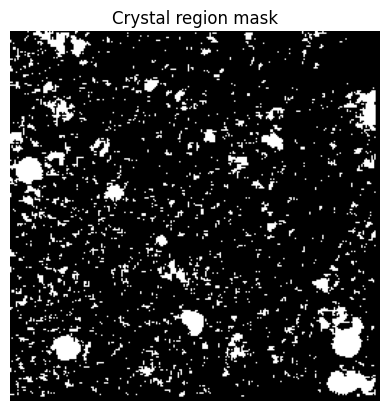

— IoU: 0.255 


In [48]:
import matplotlib.image as mpimg

target_cluster = 4
label_file = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/Labels/20220202_Ag_UTC_330kx_2650e_0p1596s_03_label.png")
truth_img = mpimg.imread(label_file)
truth_mask = (truth_img > 0)  

mask = np.isin(test_label_image, [4]).astype(np.uint8)

clean_mask = remove_small_objects(mask, max_size=100)
clean_mask = binary_fill_holes(clean_mask)
clean_mask = binary_closing(clean_mask, footprint=disk(2))

plt.imshow(clean_mask, cmap="gray")
plt.title("Crystal region mask")
plt.axis("off")
plt.show()

intersection = (clean_mask & truth_mask).sum()
union        = (clean_mask | truth_mask).sum()

iou  = intersection / union                              

print(f"— IoU: {iou:.3f} ")

/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/skimage/_shared/utils.py:386: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  return func(*args, **kwargs)
/tmp/ipykernel_121101/3891637305.py:3: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean_mask = binary_closing(clean_mask, footprint=disk(2))


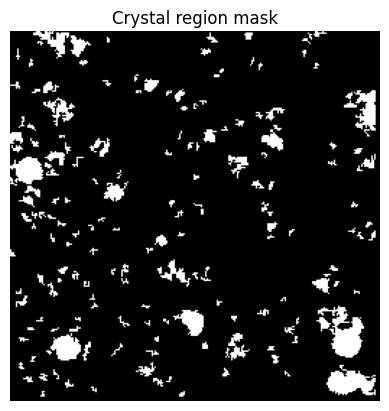

In [32]:
clean_mask = remove_small_objects(mask, max_size=100)
clean_mask = binary_fill_holes(clean_mask)
clean_mask = binary_closing(clean_mask, footprint=disk(2))
clean_mask = remove_small_objects(clean_mask, max_size=1600)

plt.imshow(clean_mask, cmap="gray")
plt.title("Crystal region mask")
plt.axis("off")
plt.show()

/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/skimage/_shared/utils.py:386: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  return func(*args, **kwargs)
/tmp/ipykernel_121101/3050581158.py:7: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean_mask = binary_closing(clean_mask, footprint=disk(2))


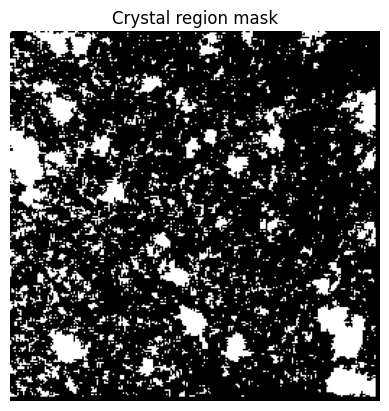

— IoU: 0.338 


In [49]:
target_cluster = 4

mask = np.isin(test_label_image, [4, 7]).astype(np.uint8)

clean_mask = remove_small_objects(mask, max_size=100)
clean_mask = binary_fill_holes(clean_mask)
clean_mask = binary_closing(clean_mask, footprint=disk(2))

plt.imshow(clean_mask, cmap="gray")
plt.title("Crystal region mask")
plt.axis("off")
plt.show()
intersection = (clean_mask & truth_mask).sum()
union        = (clean_mask | truth_mask).sum()

iou  = intersection / union                              

print(f"— IoU: {iou:.3f} ")

/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/skimage/_shared/utils.py:386: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  return func(*args, **kwargs)
/tmp/ipykernel_121101/2959682280.py:3: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean_mask = binary_closing(clean_mask, footprint=disk(2))


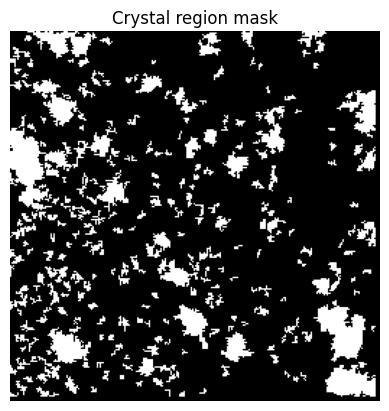

— IoU: 0.355 


In [50]:
clean_mask = remove_small_objects(mask, max_size=100)
clean_mask = binary_fill_holes(clean_mask)
clean_mask = binary_closing(clean_mask, footprint=disk(2))
clean_mask = remove_small_objects(clean_mask, max_size=1800)

plt.imshow(clean_mask, cmap="gray")
plt.title("Crystal region mask")
plt.axis("off")
plt.show()
intersection = (clean_mask & truth_mask).sum()
union        = (clean_mask | truth_mask).sum()

iou  = intersection / union                              

print(f"— IoU: {iou:.3f} ")

Persistence Image Application

In [36]:
cluster_avg_images = {}
for label in np.unique(labels):
    indices = np.where(labels == label)[0]
    cluster_vecs = vectorised_patches[indices]
    avg_vec = cluster_vecs.mean(axis=0)
    cluster_avg_images[label] = avg_vec

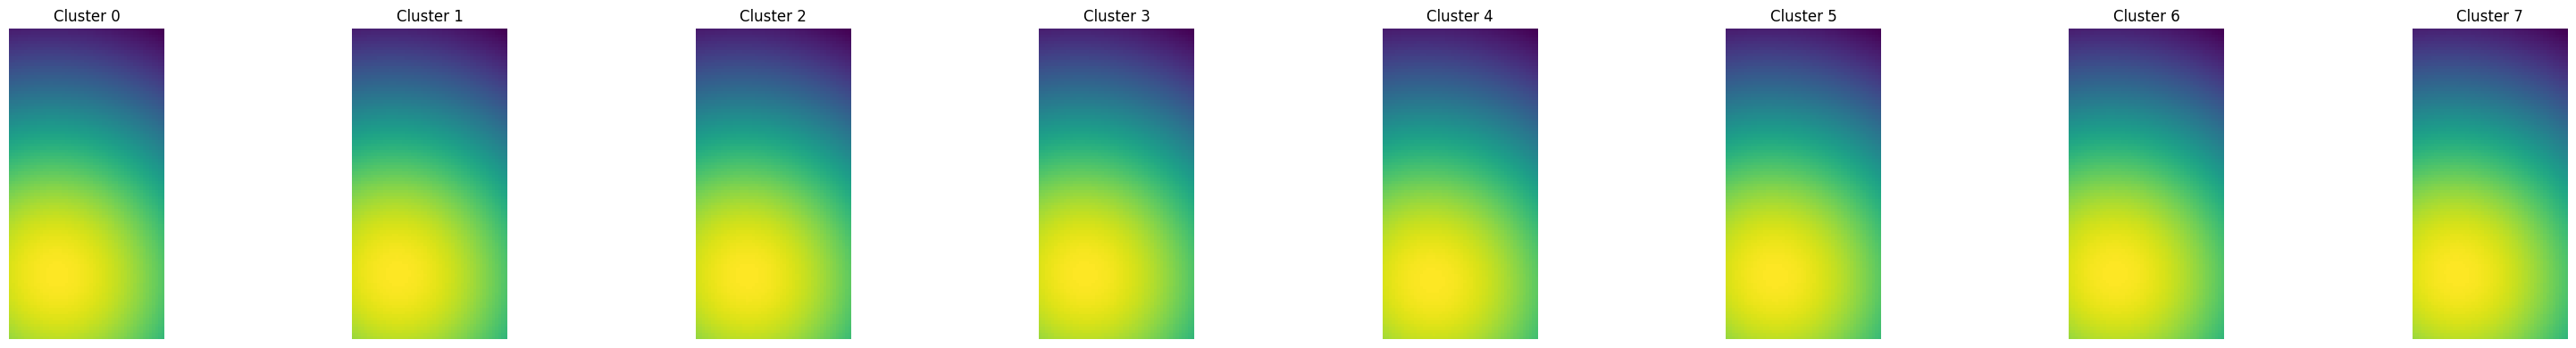

In [42]:
cluster_labels_sorted = sorted(cluster_avg_images.keys())
n = len(cluster_labels_sorted)

fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
if n == 1:
    axes = [axes]

for ax, label in zip(axes, cluster_labels_sorted):
    img = cluster_avg_images[label]
    if img.ndim == 1:
        img = img.reshape(pimgr.resolution)  # reshape if it's flattened
    ax.imshow(img, origin="lower", cmap="viridis")
    ax.set_title(f"Cluster {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [40]:
from scipy.spatial.distance import cdist

# 1. Build centroid matrix from your per-cluster average PI vectors
cluster_labels_sorted = sorted(cluster_avg_images.keys())
centroids = np.stack([cluster_avg_images[l].ravel() for l in cluster_labels_sorted])  # (n_clusters, n_pixels)

# 2. Flatten patch vectors to match centroid shape
patch_vectors = np.array([v.ravel() for v in test_vectorised_patches])  # (n_patches, n_pixels)

# 3. Compute distance from every patch to every centroid
dists = cdist(patch_vectors, centroids, metric="euclidean")  # (n_patches, n_clusters)

# 4. Assign each patch to its nearest centroid
nearest_idx = np.argmin(dists, axis=1)
patch_labels = np.array([cluster_labels_sorted[i] for i in nearest_idx])

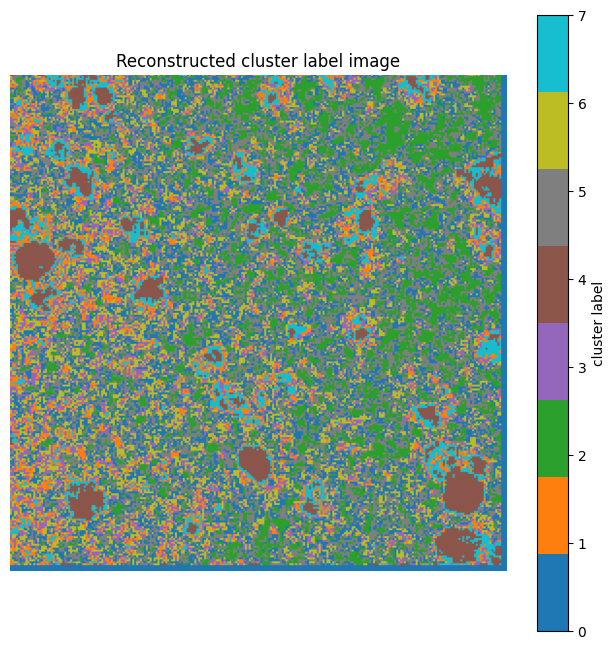

In [52]:
test_label_image_pi = label_to_image(test_image_data, patch_labels, test_positions )

n_clusters = len(cluster_densities)
cmap = plt.get_cmap("tab10", n_clusters)
cmap.set_under("black")  # colour for uncovered (-1) pixels

plt.figure(figsize=(8, 8))
plt.imshow(test_label_image_pi, cmap=cmap, vmin=0, vmax=n_clusters - 1)
plt.colorbar(ticks=range(n_clusters), label="cluster label")
plt.title("Reconstructed cluster label image")
plt.axis("off")
plt.show()

/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/skimage/_shared/utils.py:386: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  return func(*args, **kwargs)
/tmp/ipykernel_121101/222847586.py:7: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean_mask = binary_closing(clean_mask, footprint=disk(2))


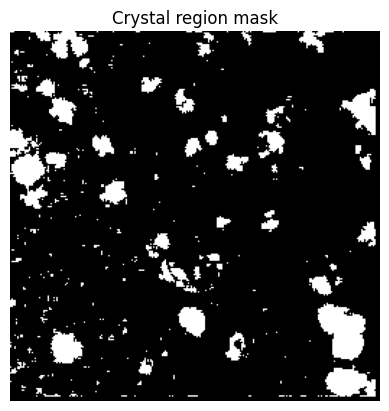

— IoU: 0.392 


In [53]:
target_cluster = 4

mask = np.isin(test_label_image_pi, [4, 7]).astype(np.uint8)

clean_mask = remove_small_objects(mask, max_size=100)
clean_mask = binary_fill_holes(clean_mask)
clean_mask = binary_closing(clean_mask, footprint=disk(2))

plt.imshow(clean_mask, cmap="gray")
plt.title("Crystal region mask")
plt.axis("off")
plt.show()
intersection = (clean_mask & truth_mask).sum()
union        = (clean_mask | truth_mask).sum()

iou  = intersection / union                              

print(f"— IoU: {iou:.3f} ")

/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/skimage/_shared/utils.py:386: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  return func(*args, **kwargs)
/tmp/ipykernel_121101/1183289902.py:7: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean_mask = binary_closing(clean_mask, footprint=disk(2))


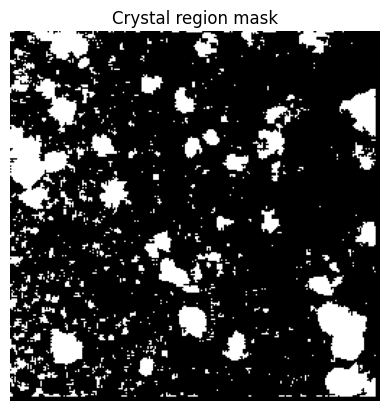

— IoU: 0.437 


In [54]:
target_cluster = 4

mask = np.isin(test_label_image_pi, [4, 7, 1]).astype(np.uint8)

clean_mask = remove_small_objects(mask, max_size=100)
clean_mask = binary_fill_holes(clean_mask)
clean_mask = binary_closing(clean_mask, footprint=disk(2))

plt.imshow(clean_mask, cmap="gray")
plt.title("Crystal region mask")
plt.axis("off")
plt.show()
intersection = (clean_mask & truth_mask).sum()
union        = (clean_mask | truth_mask).sum()

iou  = intersection / union                              

print(f"— IoU: {iou:.3f} ")